In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

E0000 00:00:1785913363.533828   57718 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785913363.538939   57718 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785913363.552157   57718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785913363.552187   57718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785913363.552189   57718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785913363.552190   57718 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1785913366.577568   57718 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 802 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1785913366.649985   57718 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 802 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1785913366.688707   57718 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 802 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1785913366.690362   57718 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 802 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1785913366.694037   57718 gpu_device.cc:2019] Create

In [2]:
def build_neural_network_structure(n_outputs):
    """
        Builds our rigid defined neural network structure where the number of output parameters is specified manually.
        That allows us to use this same function to call the different model architectures we propose here.
    """
    def neural_network(model, seed = None):
        initializer = initializers.GlorotNormal(seed = seed)
        
        model.convolution1 = keras.layers.Conv2D(filters = 4, kernel_size = [7,7], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling1 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.convolution2 = keras.layers.Conv2D(filters = 8, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling2 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.convolution3 = keras.layers.Conv2D(filters = 16, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling3 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
        model.convolution4 = keras.layers.Conv2D(filters = 32, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.pooling4 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
        model.convolution5 = keras.layers.Conv2D(filters = 64, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.pooling5 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.flatten = keras.layers.Reshape(target_shape=(-1,))
        model.dense1 = keras.layers.Dense(units = 128, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.dense2 = keras.layers.Dense(units = 4, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.dense3 = keras.layers.Dense(units = n_outputs, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = False)
        
    def neural_network_call(model, x_input, training = False):
        x = model.convolution1(x_input)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        x = model.convolution3(x)
        x = model.pooling3(x)
        x = model.convolution4(x)
        x = model.pooling4(x)
        x = model.convolution5(x)
        x = model.pooling5(x)
        x = model.flatten(x)
        x = model.dense1(x)
        x = model.dense2(x)
        x = model.dense3(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.convolution1(x_input)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        x = model.convolution3(x)
        x = model.pooling3(x)
        x = model.convolution4(x)
        x = model.pooling4(x)
        x = model.convolution5(x)
        x = model.pooling5(x)
        x = model.flatten(x)
        x = model.dense1(x)
        x = model.dense2(x)
        return x

    return neural_network, neural_network_call, neural_network_call_nolast

In [3]:
df = pd.read_csv("OASIS Data/patients_full_data.csv")
print("Data dimensions: {}".format(df.shape))
df.head(3)

Data dimensions: (737, 278)


,Unnamed: 0,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


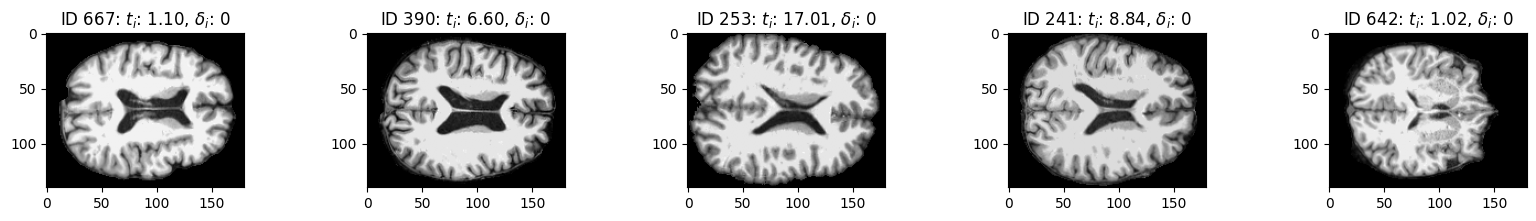

In [4]:
x = np.load("OASIS Data/patients_images.npy")
x = np.expand_dims(x, axis=-1)

np.random.seed(12)

random_idx = np.random.choice(np.arange(x.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20,2))

for i, a in enumerate(ax):
    idx = random_idx[i]
    a.imshow(x[idx,:,:,0], cmap = "gray")
    a.set_title(r"ID {}: $t_i$: {:.2f}, $\delta_i$: {}".format(idx, df.loc[idx, "time_days"] / 365, df.loc[idx, "delta"]))

Events that happened after 12 years: 6
Train dimension: (552,)
Test dimension: (185,)


(0.0, 1.05)

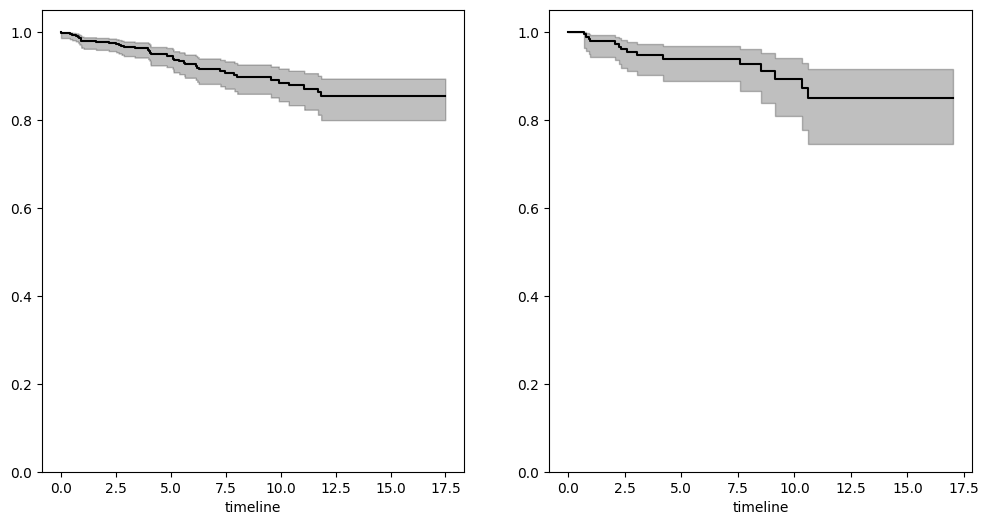

In [5]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("OASIS Data/patients_full_data.csv")

# Take long term patients that experienced the event
# In order to properly identify a cure fraction, we specify an overall limit of 15 years
# Patients whose lifetime surpasses 15 are censored
long_term_limit = 12
long_term_patients = (df["time_days"] / 365) > long_term_limit
long_term_events = long_term_patients & (df["delta"] == 1)
print("Events that happened after {} years: {}".format(long_term_limit, long_term_events.sum()))
df.loc[long_term_events, "time_days"] = long_term_limit
df.loc[long_term_patients, "delta"] = 0

indices = np.arange(df.shape[0])
idx_train, idx_test = train_test_split(indices, train_size = 0.75, random_state = 15, stratify = df["delta"])

print("Train dimension: {}".format(idx_train.shape))
print("Test dimension: {}".format(idx_test.shape))

y_train = df.loc[idx_train, "time_days"] / 365
y_test = df.loc[idx_test, "time_days"] / 365
delta_train = df.loc[idx_train, "delta"]
delta_test = df.loc[idx_test, "delta"]

x_train = x[idx_train]
x_test = x[idx_test]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

ax[0].set_ylim(0, 1.05)
ax[1].set_ylim(0, 1.05)

In [6]:
def load_weibull_model(dist, model_type, filename,
                       y_train, delta_train, x_train, y_test, delta_test, x_test,
                       fixed_q = 0.0, ngrid = 100):
    weibull_spec = mpscr.BaseWeibull()
    # Include the directory for the Weibull model results
    filename = "OASIS Results/WeibullBase/{}".format(filename)

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, weibull_spec, seed = 10 )
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = ngrid)
    elif(model_type == "medium"):
        with tf.device("/GPU:0"):
            medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = build_neural_network_structure(1)
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, weibull_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = ngrid)
    
    
    return model, model_results

In [7]:
poisson_simple_model, poisson_simple_results = load_weibull_model("poisson", "simple", "poisson_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model, bin5_simple_results = load_weibull_model("bin", "simple", "bin5_simple",
                                                            y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                            fixed_q = 5)
negbin_simple_model, negbin_simple_results = load_weibull_model("negbin", "simple", "negbin_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model, log_simple_results = load_weibull_model("log", "simple", "log_simple",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model, rgp_simple_results = load_weibull_model("rgp", "simple", "rgp_simple",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/WeibullBase/poisson_simple.
Model successfully loaded from OASIS Results/WeibullBase/bin5_simple.
Model successfully loaded from OASIS Results/WeibullBase/negbin_simple.
Model successfully loaded from OASIS Results/WeibullBase/log_simple.
Model successfully loaded from OASIS Results/WeibullBase/rgp_simple.


In [8]:
poisson_medium_model, poisson_medium_results = load_weibull_model("poisson", "medium", "poisson_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model, bin5_medium_results = load_weibull_model("bin", "medium", "bin5_medium",
                                                            y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                            fixed_q = 5)
negbin_medium_model, negbin_medium_results = load_weibull_model("negbin", "medium", "negbin_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model, log_medium_results = load_weibull_model("log", "medium", "log_medium",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model, rgp_medium_results = load_weibull_model("rgp", "medium", "rgp_medium",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/WeibullBase/poisson_medium.


W0000 00:00:1785913370.003118   57718 gpu_utils.cc:68] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.
I0000 00:00:1785913370.034466   57718 cuda_dnn.cc:529] Loaded cuDNN version 92500
Could not load symbol cuStreamGetGreenCtx. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuStreamGetGreenCtx


Model successfully loaded from OASIS Results/WeibullBase/bin5_medium.
Model successfully loaded from OASIS Results/WeibullBase/negbin_medium.
Model successfully loaded from OASIS Results/WeibullBase/log_medium.
Model successfully loaded from OASIS Results/WeibullBase/rgp_medium.


In [9]:
resid_poisson_simple_train = utils.compute_randomized_residuals_censoring( poisson_simple_results["S_train"], poisson_simple_results["delta_train"] )
resid_bin5_simple_train = utils.compute_randomized_residuals_censoring( bin5_simple_results["S_train"], bin5_simple_results["delta_train"] )
resid_negbin_simple_train = utils.compute_randomized_residuals_censoring( negbin_simple_results["S_train"], negbin_simple_results["delta_train"] )
resid_log_simple_train = utils.compute_randomized_residuals_censoring( log_simple_results["S_train"], log_simple_results["delta_train"] )
resid_rgp_simple_train = utils.compute_randomized_residuals_censoring( rgp_simple_results["S_train"], rgp_simple_results["delta_train"] )

resid_poisson_simple_test = utils.compute_randomized_residuals_censoring( poisson_simple_results["S_test"], poisson_simple_results["delta_test"] )
resid_bin5_simple_test = utils.compute_randomized_residuals_censoring( bin5_simple_results["S_test"], bin5_simple_results["delta_test"] )
resid_negbin_simple_test = utils.compute_randomized_residuals_censoring( negbin_simple_results["S_test"], negbin_simple_results["delta_test"] )
resid_log_simple_test = utils.compute_randomized_residuals_censoring( log_simple_results["S_test"], log_simple_results["delta_test"] )
resid_rgp_simple_test = utils.compute_randomized_residuals_censoring( rgp_simple_results["S_test"], rgp_simple_results["delta_test"] )

In [10]:
resid_poisson_medium_train = utils.compute_randomized_residuals_censoring( poisson_medium_results["S_train"], poisson_medium_results["delta_train"] )
resid_bin5_medium_train = utils.compute_randomized_residuals_censoring( bin5_medium_results["S_train"], bin5_medium_results["delta_train"] )
resid_negbin_medium_train = utils.compute_randomized_residuals_censoring( negbin_medium_results["S_train"], negbin_medium_results["delta_train"] )
resid_log_medium_train = utils.compute_randomized_residuals_censoring( log_medium_results["S_train"], log_medium_results["delta_train"] )
resid_rgp_medium_train = utils.compute_randomized_residuals_censoring( rgp_medium_results["S_train"], rgp_medium_results["delta_train"] )

resid_poisson_medium_test = utils.compute_randomized_residuals_censoring( poisson_medium_results["S_test"], poisson_medium_results["delta_test"] )
resid_bin5_medium_test = utils.compute_randomized_residuals_censoring( bin5_medium_results["S_test"], bin5_medium_results["delta_test"] )
resid_negbin_medium_test = utils.compute_randomized_residuals_censoring( negbin_medium_results["S_test"], negbin_medium_results["delta_test"] )
resid_log_medium_test = utils.compute_randomized_residuals_censoring( log_medium_results["S_test"], log_medium_results["delta_test"] )
resid_rgp_medium_test = utils.compute_randomized_residuals_censoring( rgp_medium_results["S_test"], rgp_medium_results["delta_test"] )

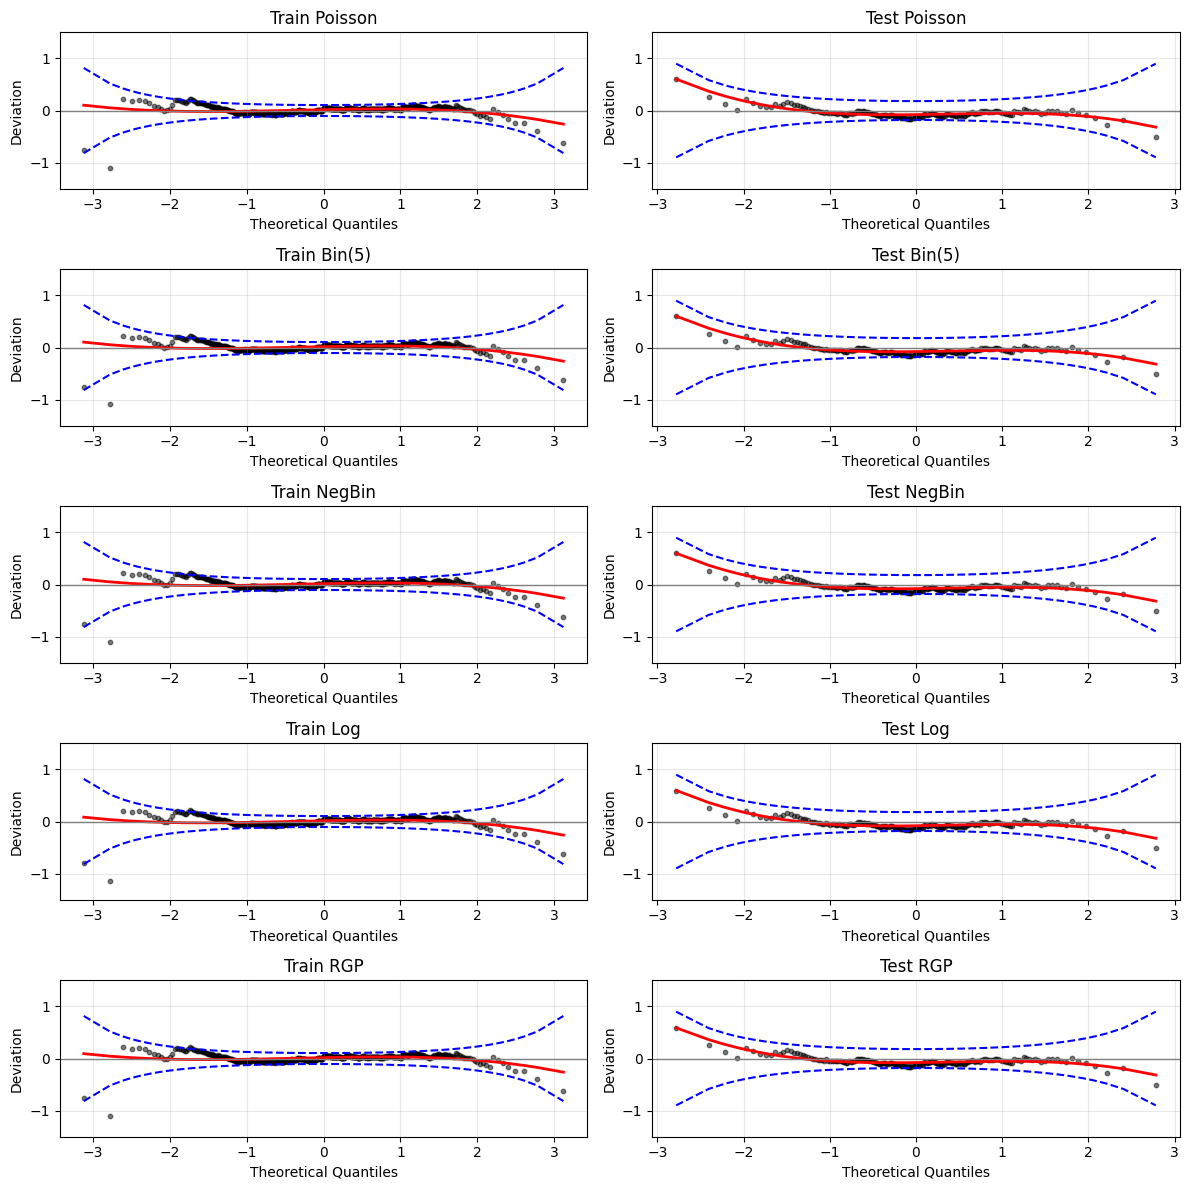

In [11]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, figsize = (12,12))

utils.plot_worm(resid_poisson_simple_train, ax = ax[0,0], title = "Train Poisson")
utils.plot_worm(resid_bin5_simple_train, ax = ax[1,0], title = "Train Bin(5)")
utils.plot_worm(resid_negbin_simple_train, ax = ax[2,0], title = "Train NegBin")
utils.plot_worm(resid_log_simple_train, ax = ax[3,0], title = "Train Log")
utils.plot_worm(resid_rgp_simple_train, ax = ax[4,0], title = "Train RGP")

utils.plot_worm(resid_poisson_simple_test, ax = ax[0,1], title = "Test Poisson")
utils.plot_worm(resid_bin5_simple_test, ax = ax[1,1], title = "Test Bin(5)")
utils.plot_worm(resid_negbin_simple_test, ax = ax[2,1], title = "Test NegBin")
utils.plot_worm(resid_log_simple_test, ax = ax[3,1], title = "Test Log")
utils.plot_worm(resid_rgp_simple_test, ax = ax[4,1], title = "Test RGP")

fig.tight_layout()
plt.show()

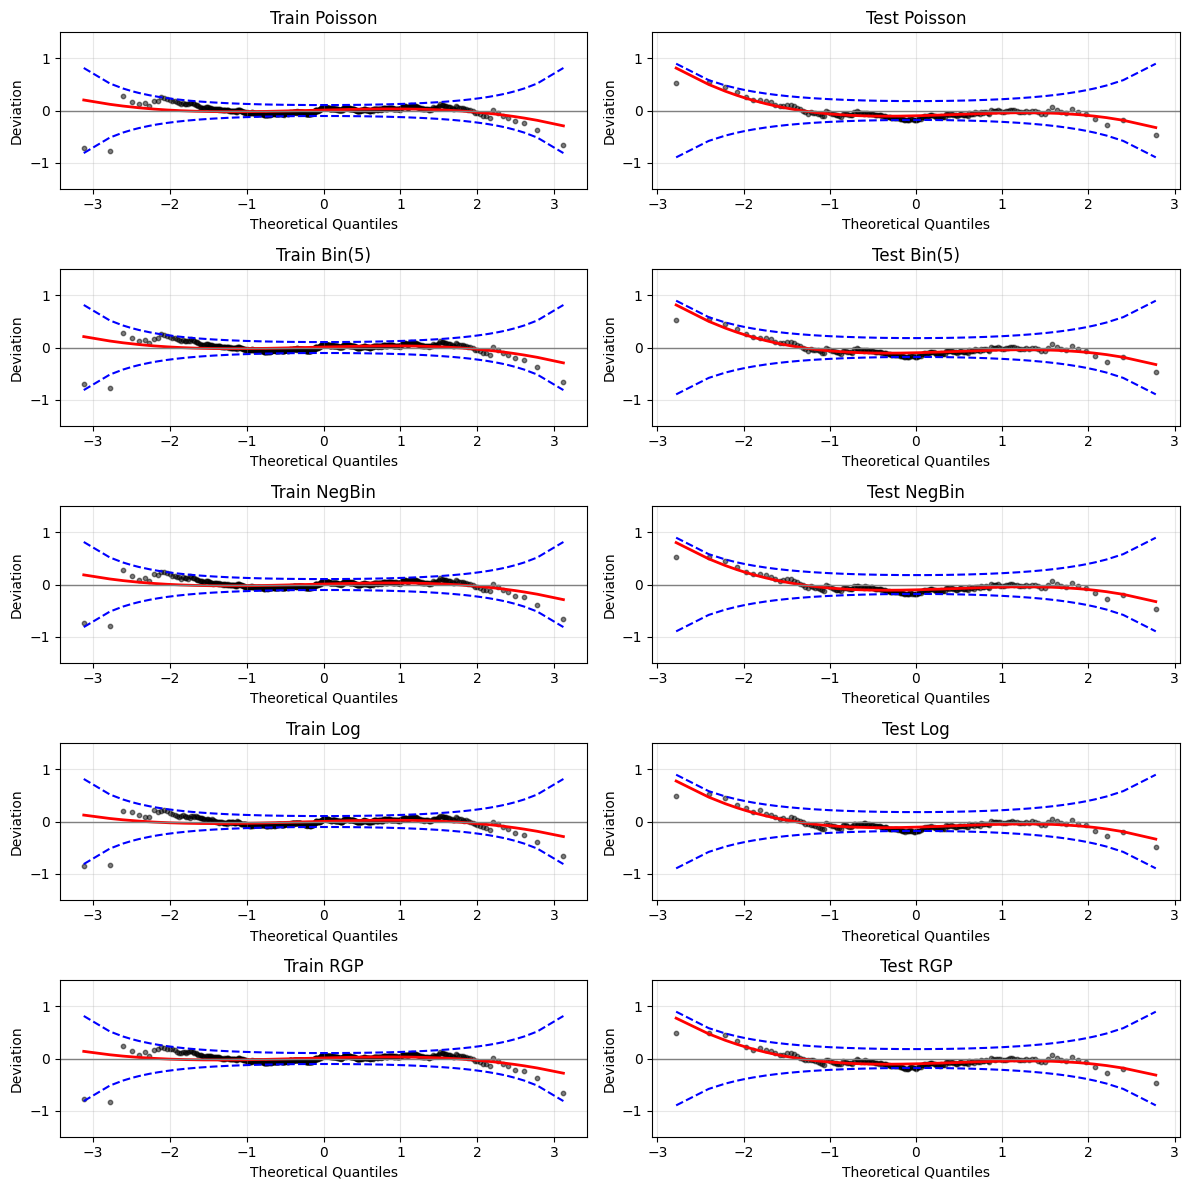

In [12]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, figsize = (12,12))

utils.plot_worm(resid_poisson_medium_train, ax = ax[0,0], title = "Train Poisson")
utils.plot_worm(resid_bin5_medium_train, ax = ax[1,0], title = "Train Bin(5)")
utils.plot_worm(resid_negbin_medium_train, ax = ax[2,0], title = "Train NegBin")
utils.plot_worm(resid_log_medium_train, ax = ax[3,0], title = "Train Log")
utils.plot_worm(resid_rgp_medium_train, ax = ax[4,0], title = "Train RGP")

utils.plot_worm(resid_poisson_medium_test, ax = ax[0,1], title = "Test Poisson")
utils.plot_worm(resid_bin5_medium_test, ax = ax[1,1], title = "Test Bin(5)")
utils.plot_worm(resid_negbin_medium_test, ax = ax[2,1], title = "Test NegBin")
utils.plot_worm(resid_log_medium_test, ax = ax[3,1], title = "Test Log")
utils.plot_worm(resid_rgp_medium_test, ax = ax[4,1], title = "Test RGP")

fig.tight_layout()
plt.show()

In [13]:
from scipy.stats import anderson

In [14]:
simple_models_resid_train = [resid_poisson_simple_train, resid_bin5_simple_train, resid_negbin_simple_train, resid_log_simple_train, resid_rgp_simple_train]
simple_models_resid_test = [resid_poisson_simple_test, resid_bin5_simple_test, resid_negbin_simple_test, resid_log_simple_test, resid_rgp_simple_test]
medium_models_resid_train = [resid_poisson_medium_train, resid_bin5_medium_train, resid_negbin_medium_train, resid_log_medium_train, resid_rgp_medium_train]
medium_models_resid_test = [resid_poisson_medium_test, resid_bin5_medium_test, resid_negbin_medium_test, resid_log_medium_test, resid_rgp_medium_test]

simple_models_train_ad = []
simple_models_test_ad = []
medium_models_train_ad = []
medium_models_test_ad = []
for i in range(len(simple_models_resid_train)):
    simple_models_train_ad.append( anderson(simple_models_resid_train[i]).statistic )
    simple_models_test_ad.append( anderson(simple_models_resid_test[i]).statistic )
    medium_models_train_ad.append( anderson(medium_models_resid_train[i]).statistic )
    medium_models_test_ad.append( anderson(medium_models_resid_test[i]).statistic )

df_results = pd.DataFrame({
    "Model": ["Poisson", "Bin(5)", "NegBin", "Log", "RGP"],
    "Simple Train": simple_models_train_ad,
    "Simple Test": simple_models_test_ad,
    "Medium Train": medium_models_train_ad,
    "Medium Test": medium_models_test_ad
})
df_results

,Model,Simple Train,Simple Test,Medium Train,Medium Test
0,Poisson,0.596969,0.380392,0.622539,0.607532
1,Bin(5),0.594823,0.379756,0.627199,0.609090
2,NegBin,0.594418,0.379061,0.600472,0.604278
3,Log,0.598480,0.378670,0.541226,0.596319
4,RGP,0.574856,0.370951,0.575250,0.583760
